#Netflix: Что смотрит мир?
Это мой pet-project по анализу данных.

Я взял датасет с Kaggle, где собрана информация обо всех фильмах и сериалах на Netflix 1925 - 2021 годов
##Цели проекта
###Проанализировать библиотеку Netflix:
- Чего больше - фильмов или сериалов?
- Какие страны производят больше всего контента?
- Какие жанры самые популярные?
- Когда Netflix любит выкладывать новинки?
###Освоение визуализации:
- Классические графики (bar, pie, histogram, heatmap)
- Интерактивные графики (Plotly)
- Продвинутые визуализации (wordcloud, choropleth map)
- Комбинированные дашборды
###Практика подготовки датасета
- Работа с пропусками (SimpleImputer)
- Парсинг дат и текста
- Создание новых фичей (feature engineering)

Датасет: https://www.kaggle.com/datasets/shivamb/netflix-shows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
df = pd.read_csv('netflix_titles.csv')

print(f'В датасете {df.shape[0]} строк и {df.shape[1]} столбцов')
print(f'То есть {df.shape[0]} фильмов/сериалов и {df.shape[1]} характеристик у каждого')

В датасете 8807 строк и 12 столбцов
То есть 8807 фильмов/сериалов и 12 характеристик у каждого


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
# Проверка есть ли пропуски в данных

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)

# Таблица, чтобы было наглядно
missing_table = pd.DataFrame({
    'Пропущено': missing,
    'Процент (%)': missing_pct
})

# Только те колонки, где реально есть пропуски
missing_table = missing_table[missing_table['Пропущено'] > 0]
missing_table = missing_table.sort_values('Процент (%)', ascending=False)

print('Пропуски в данных:')
print(missing_table)

Пропуски в данных:
            Пропущено  Процент (%)
director         2634         29.9
cast              825          9.4
country           831          9.4
date_added         10          0.1
rating              4          0.0
duration            3          0.0


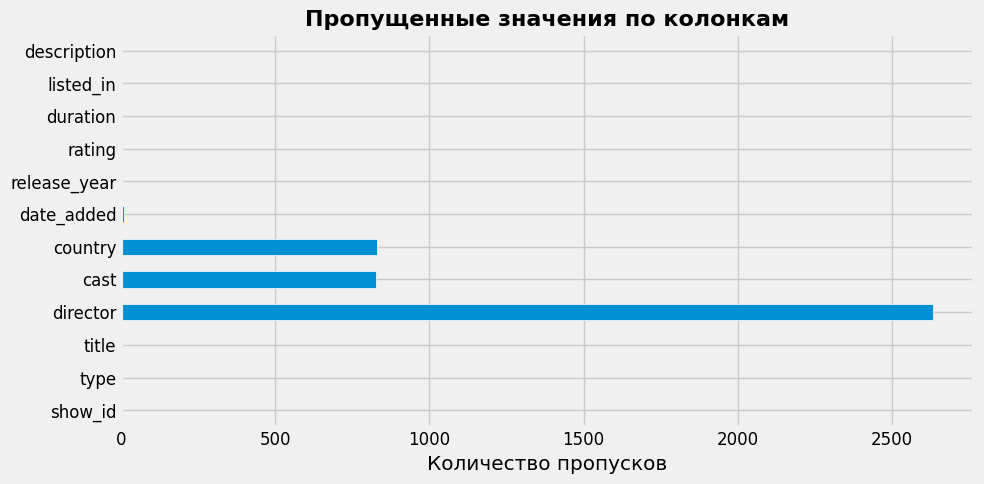

In [7]:
# Визуализирую пропуски
fig, ax = plt.subplots(figsize=(10, 5))

df.isnull().sum().plot(kind='barh', ax=ax, edgecolor='white')
ax.set_title('Пропущенные значения по колонкам', fontsize=16, fontweight='bold')
ax.set_xlabel('Количество пропусков')

plt.tight_layout()
plt.savefig('01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.impute import SimpleImputer

# Импутеры для разных типов данных

# Для текстовых колонок заполняю константой "Не указано"
text_imputer = SimpleImputer(strategy='constant', fill_value='Не указано')

# Для категориальных колонок заполняю самым частым значением (мода)
mode_imputer = SimpleImputer(strategy='most_frequent')

text_columns = ['director', 'cast', 'country']
df[text_columns] = text_imputer.fit_transform(df[text_columns])
# Рейтинг заполняю самым частым значением
df[['rating']] = mode_imputer.fit_transform(df[['rating']])

# Duration тоже самым частым
df[['duration']] = mode_imputer.fit_transform(df[['duration']])

# Description константой
desc_imputer = SimpleImputer(strategy='constant', fill_value='Описание отсутствует')
df[['description']] = desc_imputer.fit_transform(df[['description']])


In [9]:
# Осталось дата, ее импутер не смог нормально исправить

# errors='coerce' ставит NaT если не получилось
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Остаток пустых дат
null_dates = df['date_added'].isna().sum()
print(f'Пустых дат: {null_dates}')

# Пустые даты заполняю 1 января года релиза
mask = df['date_added'].isna()
df.loc[mask, 'date_added'] = pd.to_datetime(
    df.loc[mask, 'release_year'].astype(int).astype(str) + '-01-01'
)

print(f'Пустых дат после заполнения: {df["date_added"].isna().sum()}')
print(f'Тип колонки date_added: {df["date_added"].dtype}')

Пустых дат: 10
Пустых дат после заполнения: 0
Тип колонки date_added: datetime64[ns]


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [11]:
# Новые колонки

# Год и месяц добавления на Netflix
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_of_week'] = df['date_added'].dt.day_name()

# Из колонки duration вытащу число (минуты или сезоны)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Первая страна из списка (бывает что указано несколько через запятую)
df['country_first'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# Количество жанров у каждого шоу
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))

print(f'Теперь в датасете {df.shape[1]} колонок')
print(f'Период данных: {df["release_year"].min()} - {df["release_year"].max()} годы')

Теперь в датасете 18 колонок
Период данных: 1925 - 2021 годы


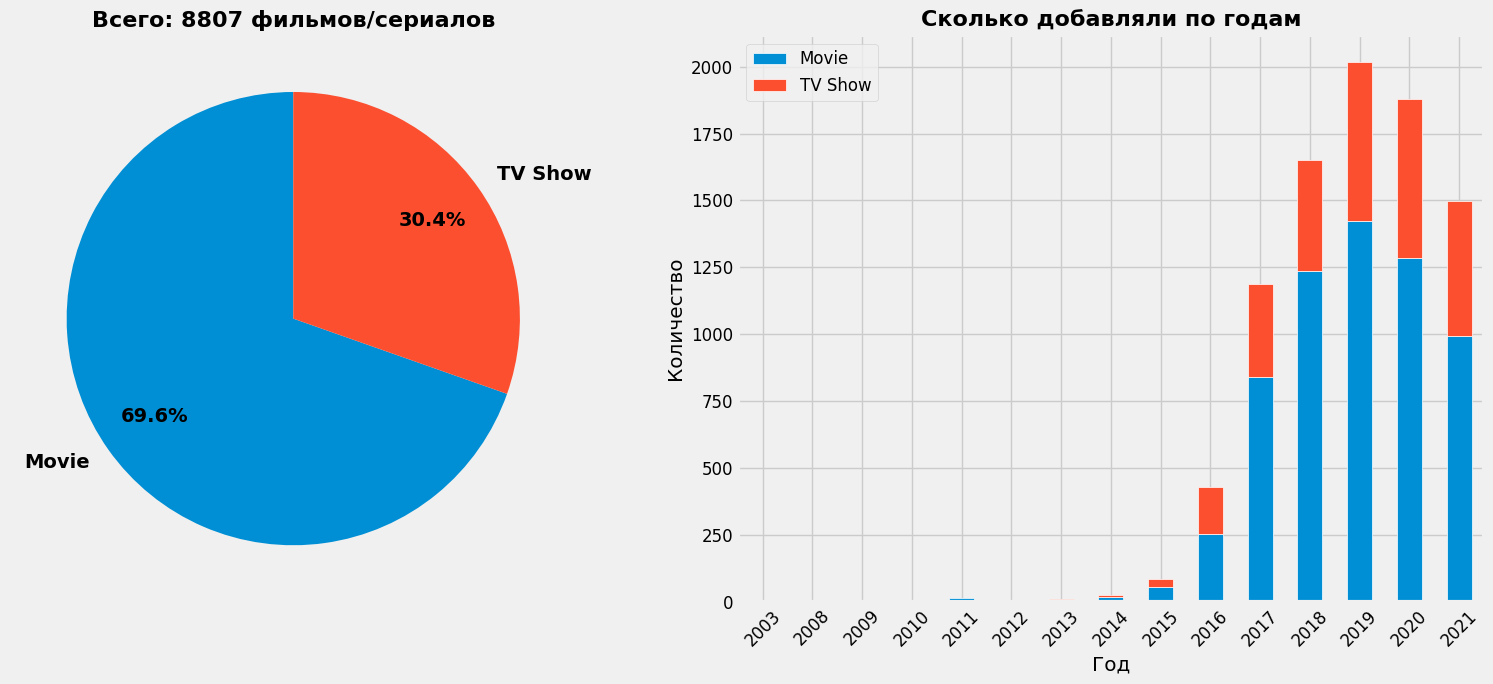

In [12]:
# Нарисую два графика количества фильмов/сериалов

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
type_counts = df['type'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

axes[0].set_title(f'Всего: {len(df)} фильмов/сериалов', fontsize=16, fontweight='bold')

type_by_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_by_year.plot(kind='bar', stacked=True, ax=axes[1],
                  edgecolor='white', linewidth=0.5)

axes[1].set_title('Сколько добавляли по годам', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Количество')
axes[1].legend(fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('02_movies_vs_shows.png', dpi=150, bbox_inches='tight')
plt.show()

# Фильмов примерно в 2 раза больше, чем сериалов.
# Но в последние годы доля сериалов растёт, возможно, по причине, что сериалы лучше удерживают подписчиков

In [13]:
# Накопительный график

fig = go.Figure()

for content_type in ['Movie', 'TV Show']:
    data = (df[df['type'] == content_type]
            .groupby('year_added')
            .size()
            .reset_index(name='count'))
    data['cumulative'] = data['count'].cumsum()


    fig.add_trace(go.Scatter(
        x=data['year_added'],
        y=data['cumulative'],
        mode='lines+markers',
        name=content_type,
        line=dict(width=3),
        marker=dict(size=7)
    ))

fig.update_layout(
    title='Как росла библиотека Netflix',
    xaxis_title='Год',
    yaxis_title='Количество выпусков (накопительно)',
    template='plotly_white',
    font=dict(size=14),
    hovermode='x unified',
    width=900,
    height=500
)

fig.write_html('03_growth.html')
fig.show()

# Резкий рост начался примерно с 2015-2016 года.
# Пик добавлений - 2019-2020. После 2020 рост замедлился, возможно, из-за пандемии и растущей конкуренции

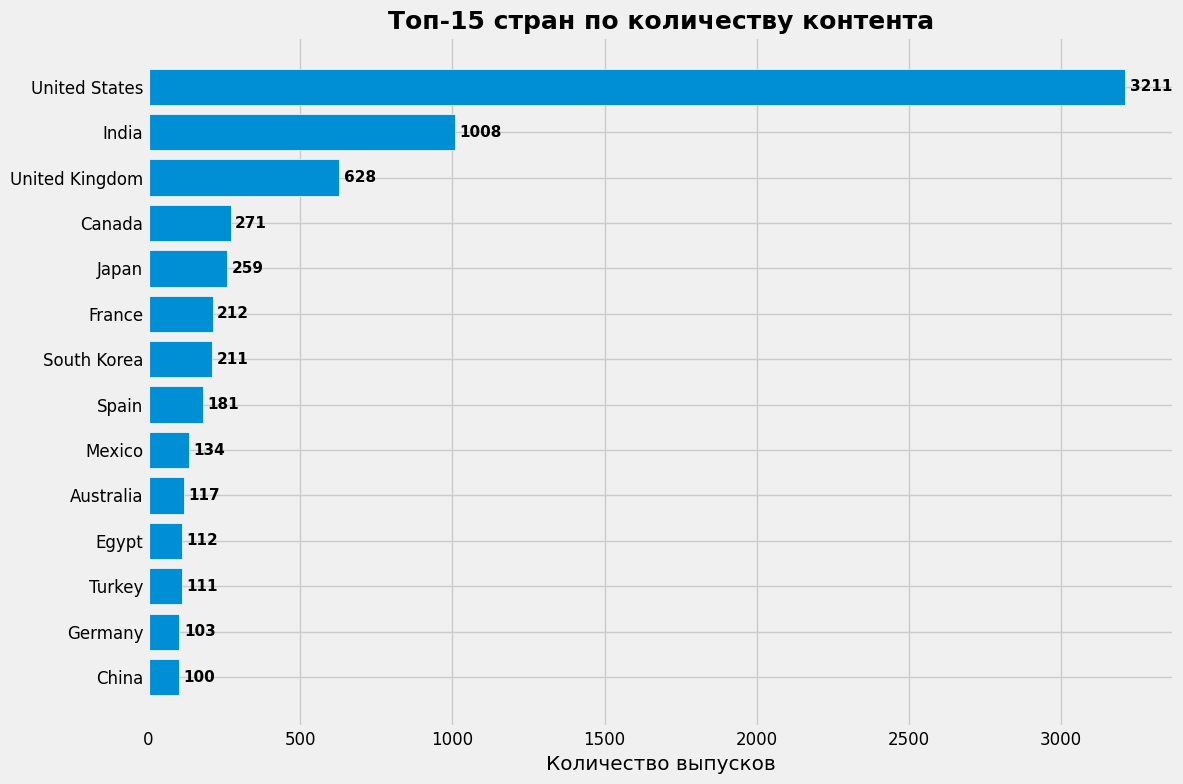

Топ-5 стран:
   1. United States - 3211 значений (36.5%)
   2. India - 1008 значений (11.4%)
   3. United Kingdom - 628 значений (7.1%)
   4. Canada - 271 значений (3.1%)
   5. Japan - 259 значений (2.9%)


In [14]:
# Контент из каких стран преобладает

top_countries = df['country_first'].value_counts().head(15)
# "Не указано" это неинформативно
top_countries = top_countries[top_countries.index != 'Не указано']

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], edgecolor='white')

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')

ax.set_title('Топ-15 стран по количеству контента', fontsize=18, fontweight='bold')
ax.set_xlabel('Количество выпусков')

plt.tight_layout()
plt.savefig('04_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

# топ-5 текстом
print('Топ-5 стран:')
for i, (country, count) in enumerate(top_countries.head(5).items(), 1):
    pct = count / len(df) * 100
    print(f'   {i}. {country} - {count} значений ({pct:.1f}%)')

# США с огромным отрывом на первом месте.
# Индия на втором - там огромная индустрия Bollywood.
# Великобритания на третьем.

In [15]:
# То же самое, но на карте мира

country_data = df['country_first'].value_counts().reset_index()
country_data.columns = ['country', 'count']
country_data = country_data[country_data['country'] != 'Не указано']

fig = px.choropleth(
    country_data,
    locations='country',
    locationmode='country names',
    color='count',
    title='Контент Netflix по странам мира',
    labels={'count': 'Значения'},
    hover_name='country'
)

fig.update_layout(
    template='plotly_white',
    font=dict(size=14),
    width=1000,
    height=550
)

fig.write_html('05_world_map.html')
fig.show()

# Видно, что Netflix - это в основном американская платформа, но с сильным присутствием индийского и европейского контента.

In [16]:
# Жанры записаны как
# "Dramas, International Movies, Thrillers"
# Нужно разбить их и посчитать каждый отдельно

# Жанры в одном большом списке
all_genres = []
for genres in df['listed_in']:
    all_genres.extend([g.strip() for g in genres.split(',')])

genre_counts = Counter(all_genres)

movies = df[df['type'] == 'Movie']
shows = df[df['type'] == 'TV Show']

movie_genres = []
for genres in movies['listed_in']:
    movie_genres.extend([g.strip() for g in genres.split(',')])

show_genres = []
for genres in shows['listed_in']:
    show_genres.extend([g.strip() for g in genres.split(',')])

movie_top10 = Counter(movie_genres).most_common(10)
show_top10 = Counter(show_genres).most_common(10)

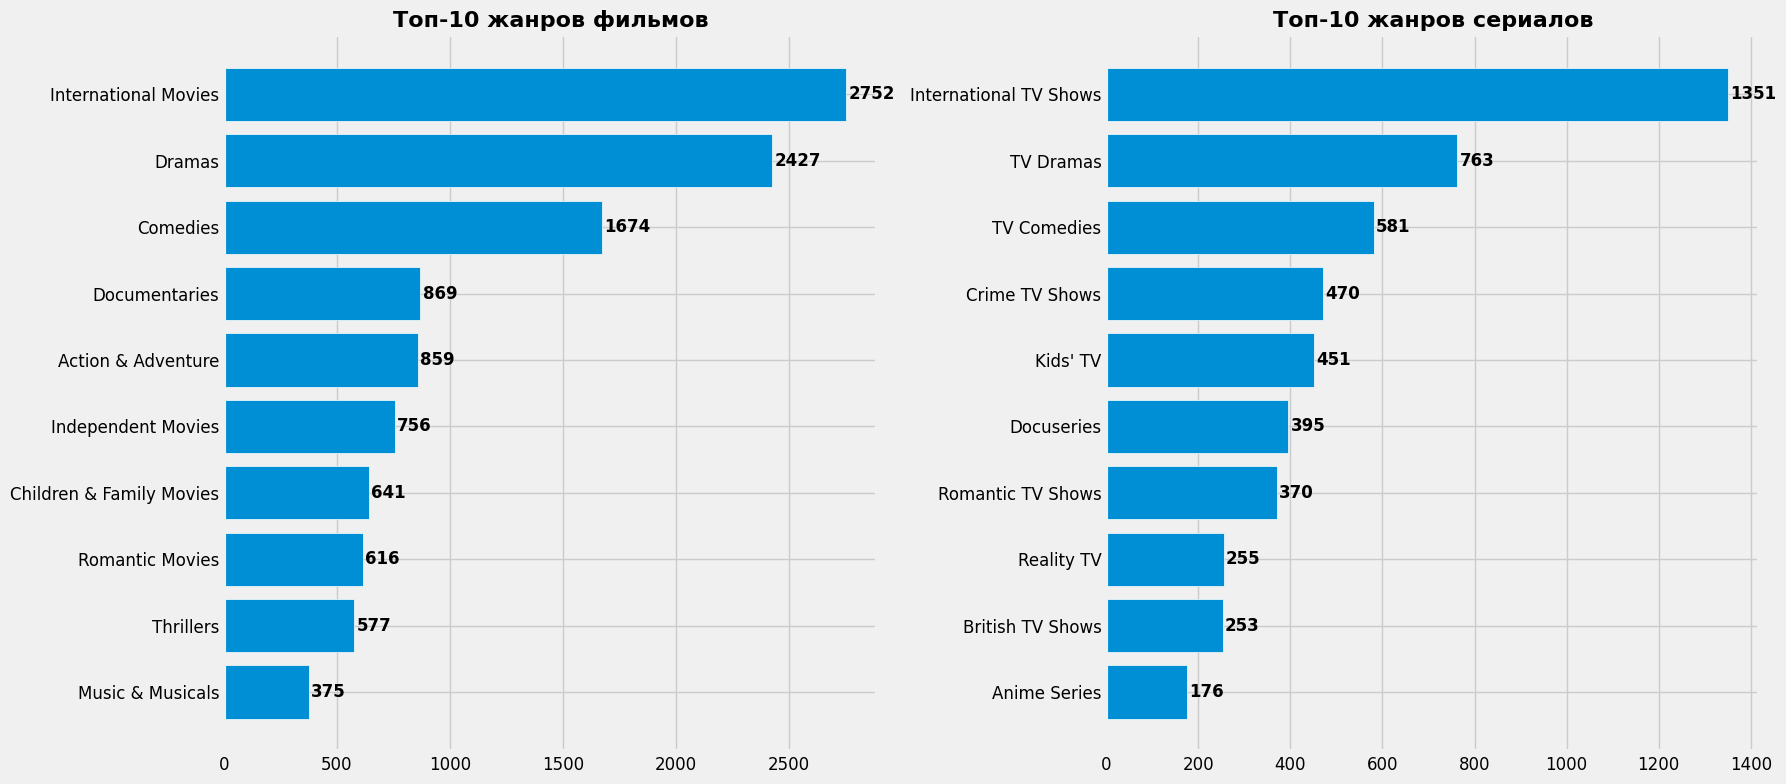

In [17]:
# Два графика - жанры фильмов и жанры сериалов

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

genres_m, counts_m = zip(*movie_top10)
axes[0].barh(genres_m[::-1], counts_m[::-1], edgecolor='white')
axes[0].set_title('Топ-10 жанров фильмов', fontsize=16, fontweight='bold')
for i, v in enumerate(counts_m[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold')

genres_s, counts_s = zip(*show_top10)
axes[1].barh(genres_s[::-1], counts_s[::-1], edgecolor='white')
axes[1].set_title('Топ-10 жанров сериалов', fontsize=16, fontweight='bold')
for i, v in enumerate(counts_s[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_genres.png', dpi=150, bbox_inches='tight')
plt.show()

# International Movies - самый частый жанр у фильмов, что логично,ведь Netflix покупает много контента из разных стран.
# У сериалов лидируют International TV Shows и TV Dramas.

In [18]:
# На Netflix у каждого фильма/сериала есть возрастной рейтинг:
# TV-MA - для взрослых, TV-14 - подростки, TV-Y - дети и т.д.
# Перепишу как:

rating_map = {
    'TV-Y': 'Дети',
    'TV-Y7': 'Дети',
    'TV-Y7-FV': 'Дети',
    'G': 'Дети',
    'TV-G': 'Дети',
    'PG': 'Подростки',
    'TV-PG': 'Подростки',
    'PG-13': 'Молодёжь',
    'TV-14': 'Молодёжь',
    'R': 'Взрослые',
    'TV-MA': 'Взрослые',
    'NC-17': 'Взрослые'
}

df['audience'] = df['rating'].map(rating_map).fillna('Другое')

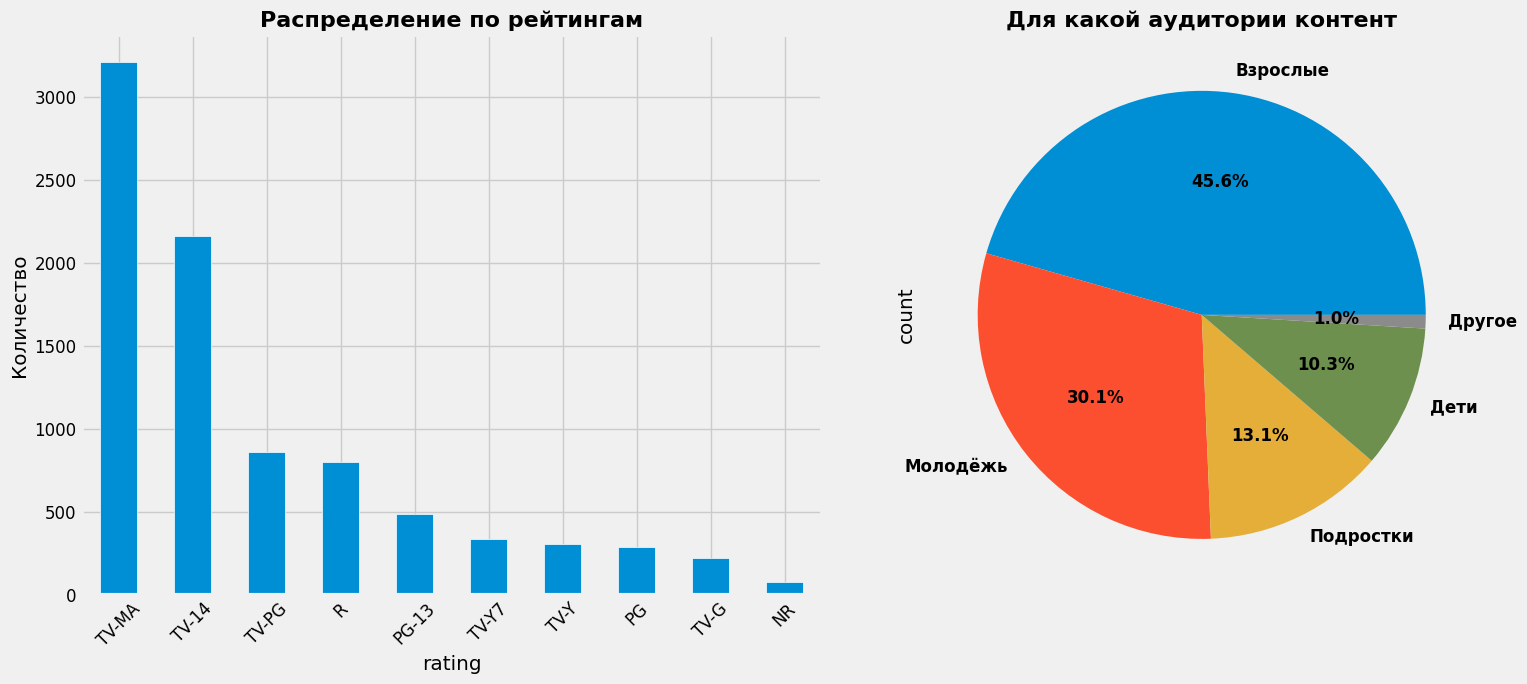

Аудитория Netflix:
   Взрослые: 4013 (45.6%)
   Молодёжь: 2650 (30.1%)
   Подростки: 1150 (13.1%)
   Дети: 908 (10.3%)
   Другое: 86 (1.0%)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Распределение по рейтингам
rating_counts = df['rating'].value_counts().head(10)
rating_counts.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Распределение по рейтингам', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Для какой аудитории контент
audience_counts = df['audience'].value_counts()

audience_counts.plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title('Для какой аудитории контент', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('07_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print('Аудитория Netflix:')
for audience, count in audience_counts.items():
    pct = count / len(df) * 100
    print(f'   {audience}: {count} ({pct:.1f}%)')

# Netflix - это преимущественно взрослая платформа
# TV-MA (для взрослых) - самый частый рейтинг
# Детского контента относительно мало

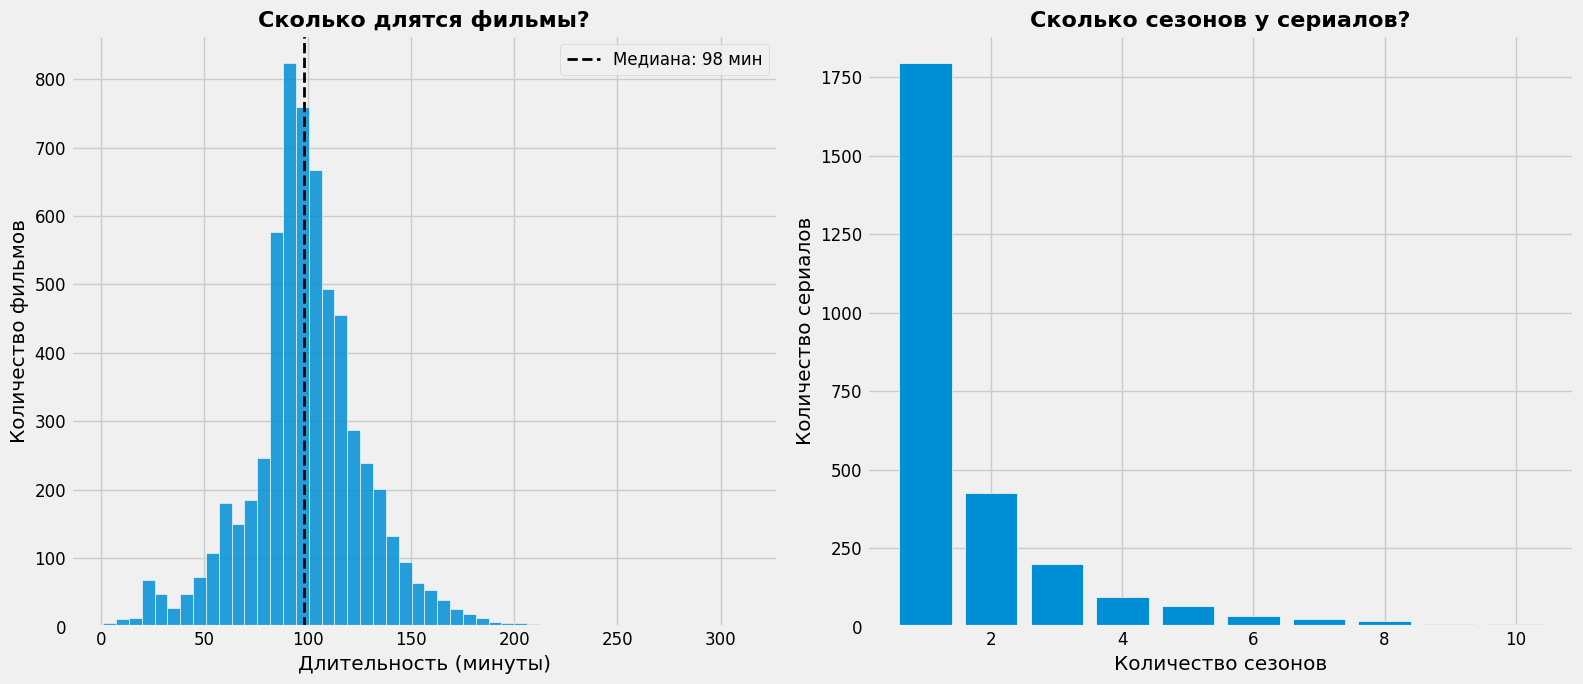

Фильмы:
   Средняя длительность: 100 мин
   Медиана: 98 мин
   Самый короткий: 1 мин
   Самый длинный: 312 мин

Сериалы:
   Среднее кол-во сезонов: 1.8
   Большинство сериалов: 1 сезон


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Длительность фильмов
movie_duration = df[df['type'] == 'Movie']['duration_num'].dropna()

axes[0].hist(movie_duration, bins=50,
             edgecolor='white', alpha=0.85)

# Медианы
median_dur = movie_duration.median()
axes[0].axvline(median_dur, color='black', linestyle='--', linewidth=2,
                label=f'Медиана: {median_dur:.0f} мин')

axes[0].set_title('Сколько длятся фильмы?', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Длительность (минуты)')
axes[0].set_ylabel('Количество фильмов')
axes[0].legend(fontsize=12)

# Сезоны сериалов
show_seasons = df[df['type'] == 'TV Show']['duration_num'].dropna()
season_counts = show_seasons.value_counts().sort_index().head(10)

axes[1].bar(season_counts.index.astype(int), season_counts.values,
            edgecolor='white')
axes[1].set_title('Сколько сезонов у сериалов?', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Количество сезонов')
axes[1].set_ylabel('Количество сериалов')

plt.tight_layout()
plt.savefig('08_duration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Фильмы:')
print(f'   Средняя длительность: {movie_duration.mean():.0f} мин')
print(f'   Медиана: {movie_duration.median():.0f} мин')
print(f'   Самый короткий: {movie_duration.min():.0f} мин')
print(f'   Самый длинный: {movie_duration.max():.0f} мин')
print()
print(f'Сериалы:')
print(f'   Среднее кол-во сезонов: {show_seasons.mean():.1f}')
print(f'   Большинство сериалов: {show_seasons.mode().values[0]:.0f} сезон')

# Типичный фильм на Netflix длится ~100 минут
# А большинство сериалов имеют всего 1 сезон - то есть Netflix часто не продлевает сериалы дальше первого сезона

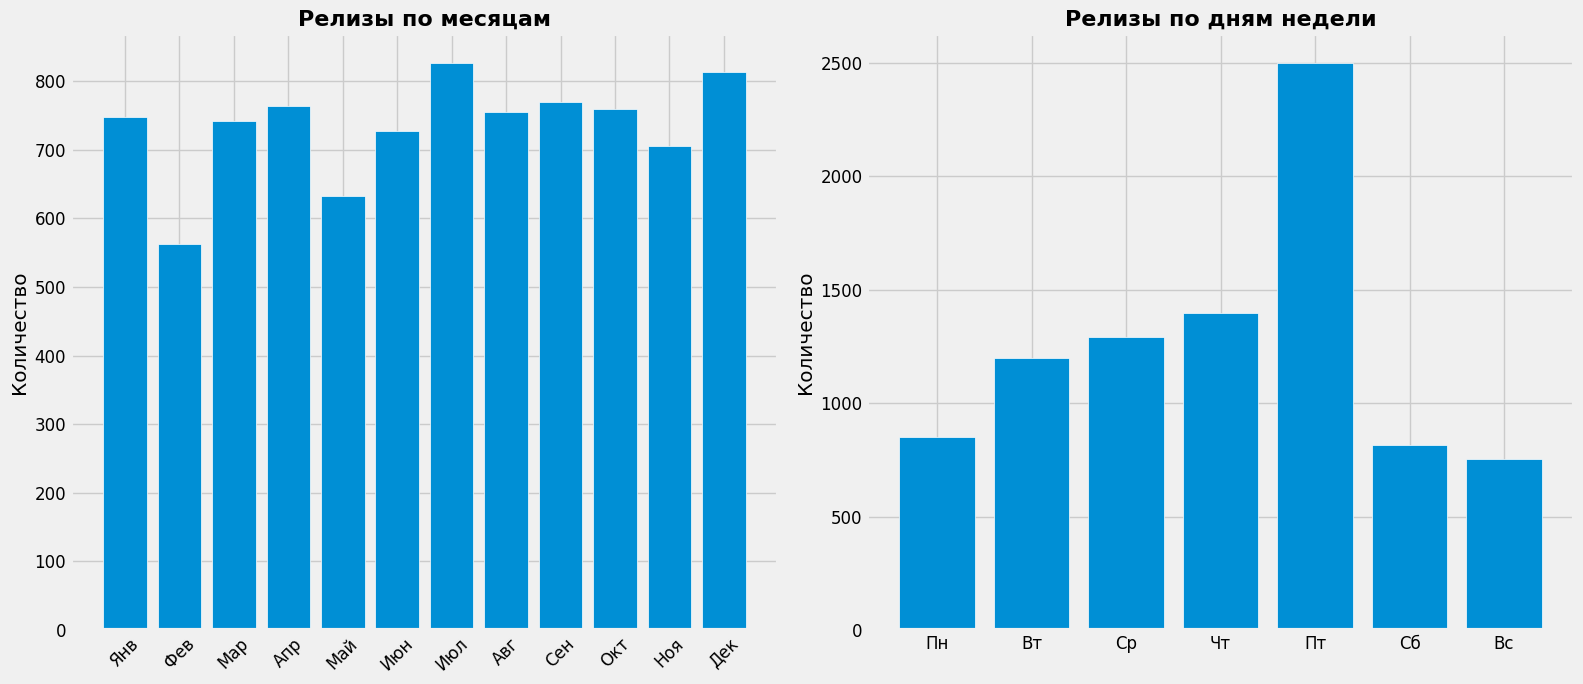

In [21]:
# Любимый день недели или месяц для релизову Netflix

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

monthly = df.groupby('month_added').size()

axes[0].bar(range(len(monthly)), monthly.values, edgecolor='white')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(month_names[:len(monthly)], rotation=45)
axes[0].set_title('Релизы по месяцам', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Количество')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
day_names_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily = df['day_of_week'].value_counts().reindex(day_order)

axes[1].bar(day_names_ru, daily.values, edgecolor='white')
axes[1].set_title('Релизы по дням недели', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('09_release_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Больше всего релизов по пятницам, скорее всего Netflix хочет, чтобы вы смотрели на выходных

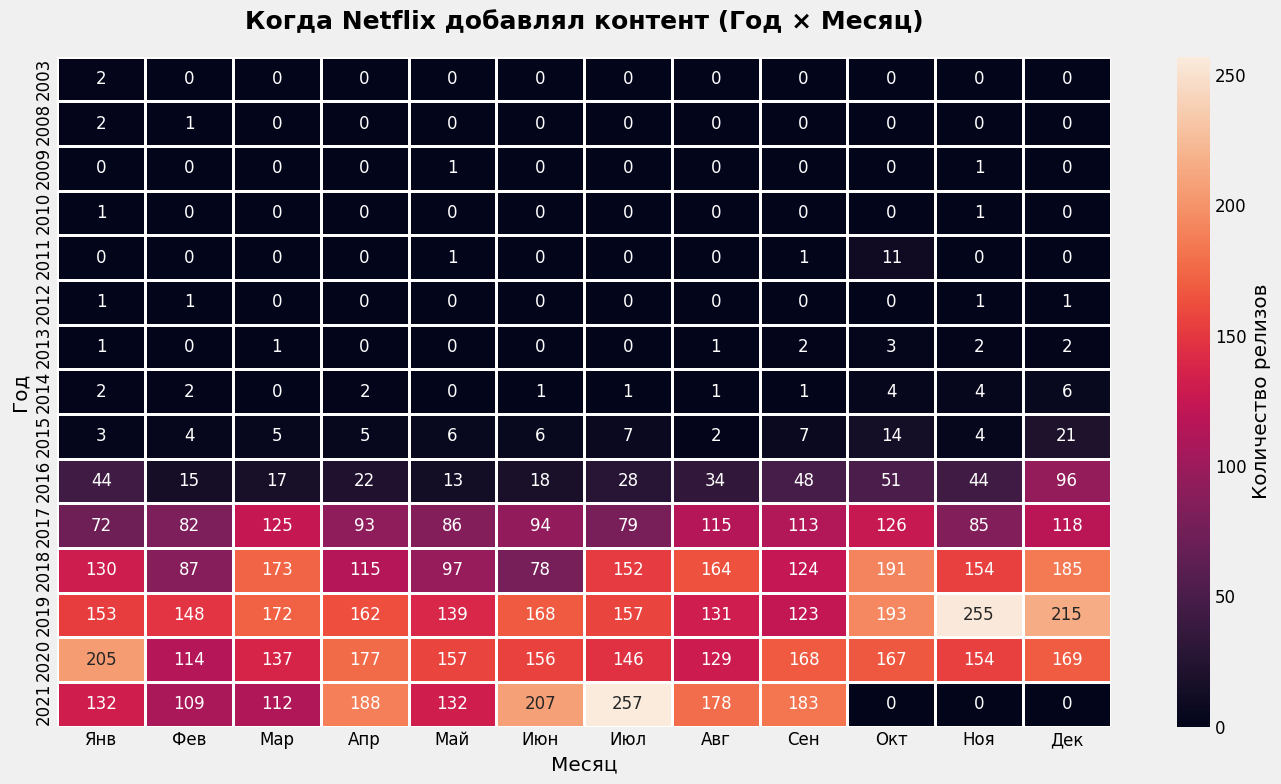

In [22]:
# Тепловая карта

heatmap_data = (df.groupby(['year_added', 'month_added'])
                .size()
                .unstack(fill_value=0))

heatmap_data = heatmap_data.loc[heatmap_data.index.dropna()]

heatmap_data.columns = month_names[:len(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(heatmap_data, annot=True, fmt='d',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Количество релизов'})

ax.set_title('Когда Netflix добавлял контент (Год × Месяц)',
             fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Год')
ax.set_xlabel('Месяц')

plt.tight_layout()
plt.savefig('10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Видно, что пик добавлений был в 2019-2020 годах. После этого активность немного снизилась.

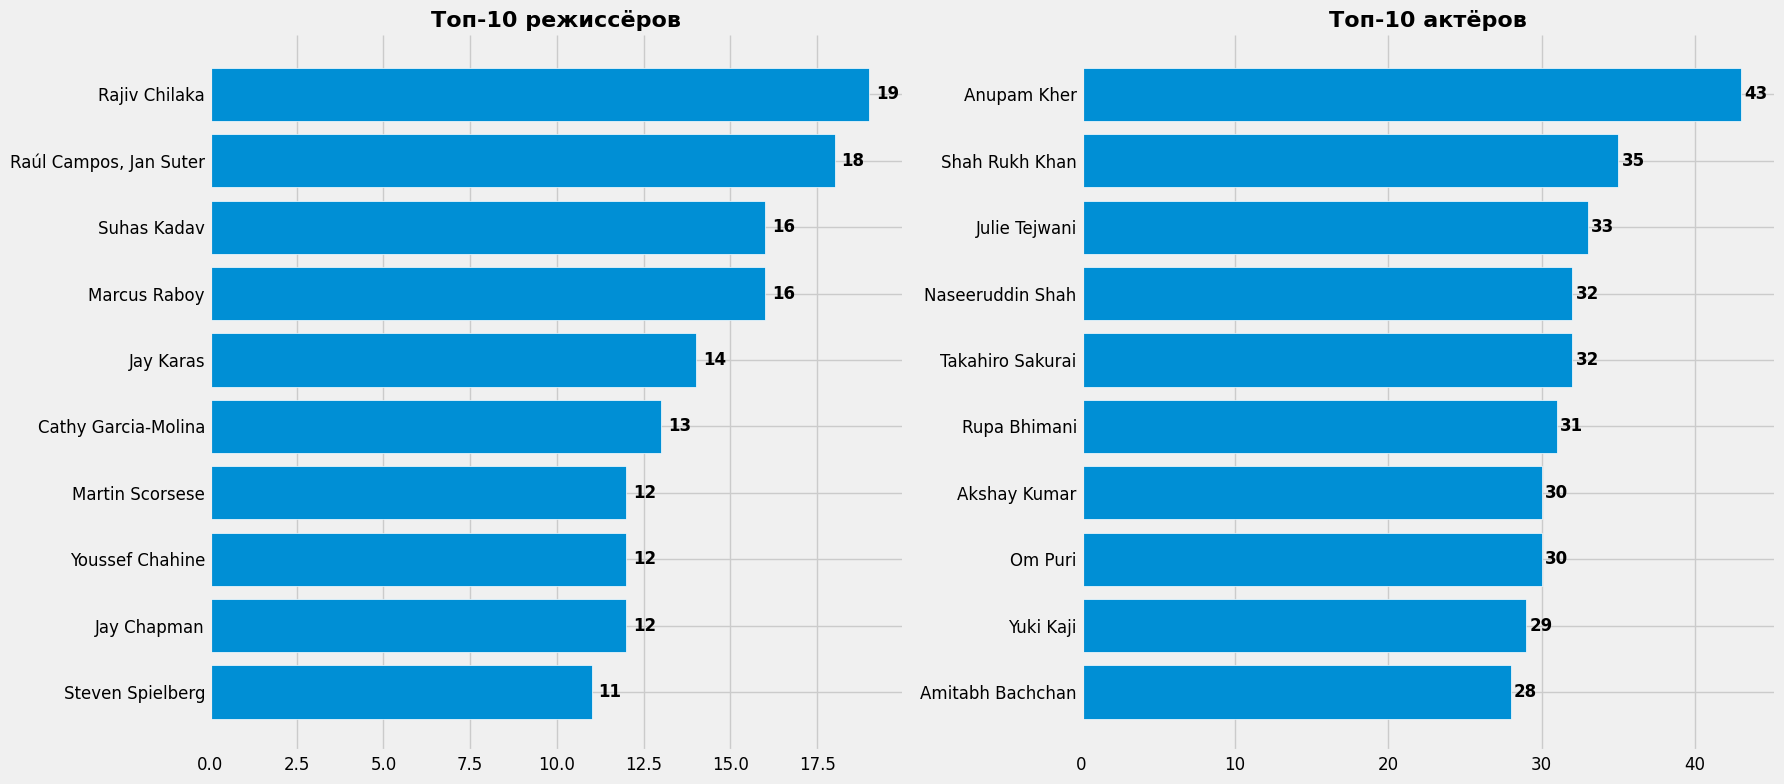

In [23]:
# Частота актеров, режиссеров

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Топ режиссеров
top_directors = (df[df['director'] != 'Не указано']['director']
                 .value_counts().head(10))

axes[0].barh(top_directors.index[::-1], top_directors.values[::-1],
             edgecolor='white')
axes[0].set_title('Топ-10 режиссёров', fontsize=16, fontweight='bold')

for i, v in enumerate(top_directors.values[::-1]):
    axes[0].text(v + 0.2, i, str(v), va='center', fontweight='bold')

# Топ актеров
all_cast = []
for cast_list in df[df['cast'] != 'Не указано']['cast']:
    all_cast.extend([c.strip() for c in cast_list.split(',')])

top_actors = Counter(all_cast).most_common(10)
actor_names, actor_counts = zip(*top_actors)

axes[1].barh(actor_names[::-1], actor_counts[::-1],
             edgecolor='white')
axes[1].set_title('Топ-10 актёров', fontsize=16, fontweight='bold')

for i, v in enumerate(actor_counts[::-1]):
    axes[1].text(v + 0.2, i, str(v), va='center', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('11_top_people.png', dpi=150, bbox_inches='tight')
plt.show()

# Среди режиссёров лидирует Rajiv Chilaka (индийская анимация)

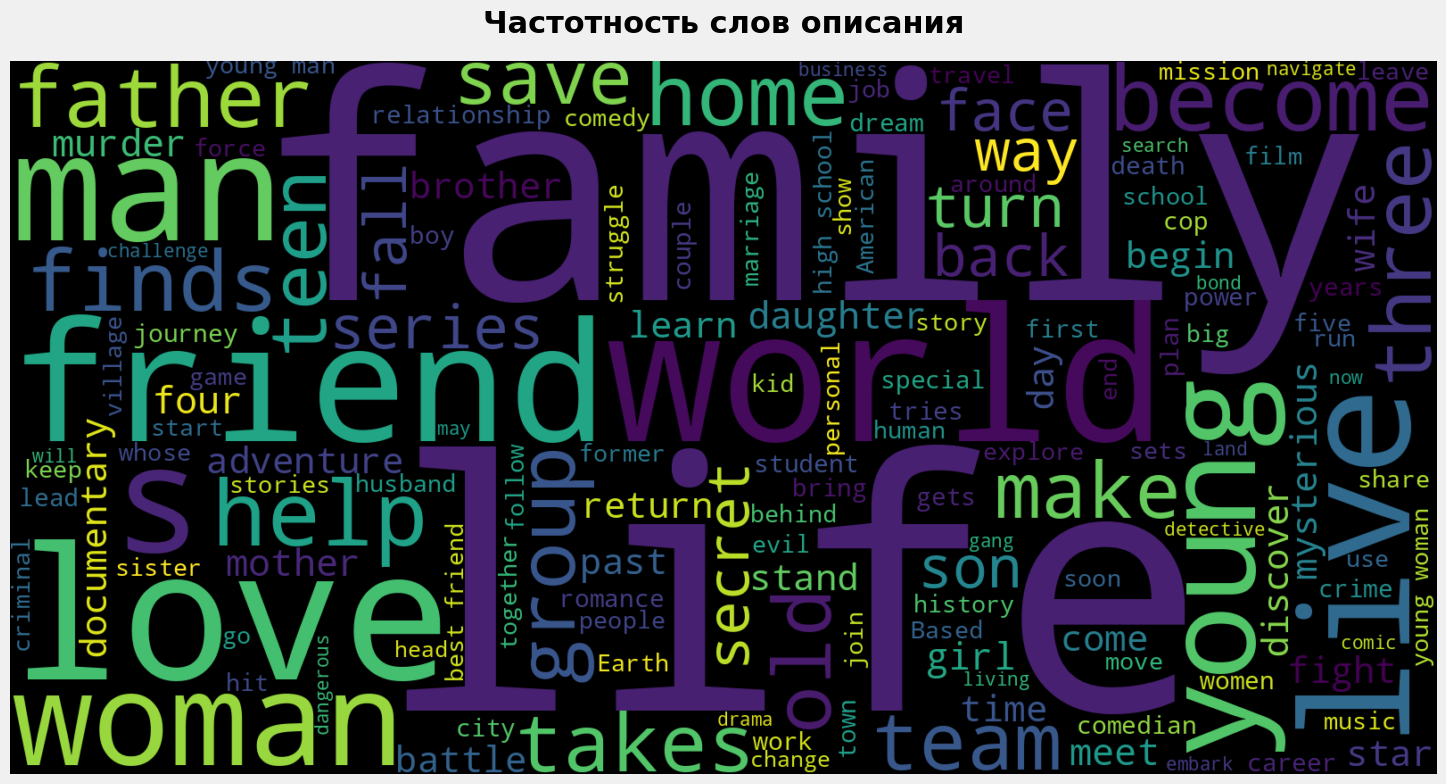

In [24]:
# Облако слов (word cloud) - красивый способ показать, какие слова чаще всего встречаются в описаниях фильмов
from wordcloud import WordCloud, STOPWORDS

text = ' '.join(df['description'].dropna().values)

stopwords = set(STOPWORDS)
stopwords.update(['one', 'two', 'new', 'find', 'must',
                  'take', 'set', 'year']) # Вылазят, но не имеют смысла

wordcloud = WordCloud(
    width=1600,
    height=800,
    stopwords=stopwords,
    max_words=150,
    random_state=42
).generate(text)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Частотность слов описания',
             fontsize=22, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('12_wordcloud.png', dpi=150, bbox_inches='tight',
            facecolor='black')
plt.show()

# Самые частые слова - family, love, life, world, friend, live
# Netflix делает ставку на истории про отношения и семью

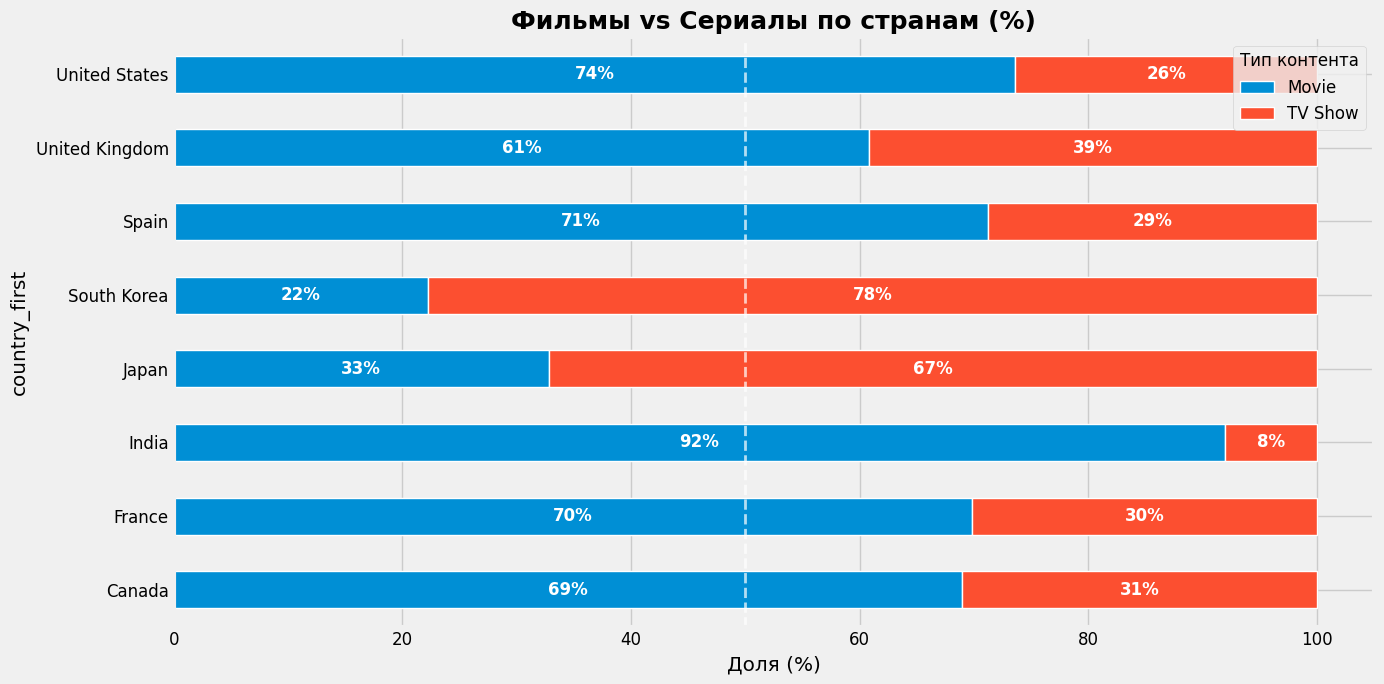

In [25]:
# Фильмы или сериалы для разных стран

# топ-8 стран (без "Не указано")
top8 = df['country_first'].value_counts().head(9).index.tolist()
top8 = [c for c in top8 if c != 'Не указано'][:8]

# Соотношение
country_type = (df[df['country_first'].isin(top8)]
                .groupby(['country_first', 'type'])
                .size()
                .unstack(fill_value=0))

country_type_pct = country_type.div(country_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

country_type_pct.plot(kind='barh', stacked=True, ax=ax,
                      edgecolor='white', linewidth=1)

ax.set_title('Фильмы vs Сериалы по странам (%)',
             fontsize=18, fontweight='bold')
ax.set_xlabel('Доля (%)')
ax.legend(title='Тип контента', fontsize=12)

# 50%
ax.axvline(x=50, color='white', linestyle='--', linewidth=2, alpha=0.7)

for i, (idx, row) in enumerate(country_type_pct.iterrows()):
    movie_pct = row.get('Movie', 0)
    show_pct = row.get('TV Show', 0)
    ax.text(movie_pct / 2, i, f'{movie_pct:.0f}%',
            ha='center', va='center', fontweight='bold', color='white')
    ax.text(movie_pct + show_pct / 2, i, f'{show_pct:.0f}%',
            ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('13_country_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

# Южная Корея и Япония имеют больше сериалов, а Индия больше фильмов

In [26]:
# Факты из этой таблицы

# Самый старый контент
oldest = df.loc[df['release_year'].idxmin()]
print(f'Самый старый контент:')
print(f'    "{oldest["title"]}" ({oldest["release_year"]} год)')

# Самый длинный фильм
movies_only = df[df['type'] == 'Movie']
longest = movies_only.loc[movies_only['duration_num'].idxmax()]
print(f'Самый длинный фильм:')
print(f'    "{longest["title"]}" ({longest["duration_num"]:.0f} мин)')

# Самый сезонный сериал
shows_only = df[df['type'] == 'TV Show']
most_seasons = shows_only.loc[shows_only['duration_num'].idxmax()]
print(f'Сериал с наибольшим числом сезонов:')
print(f'    "{most_seasons["title"]}" ({most_seasons["duration_num"]:.0f} сезонов)')

# Самый продуктивный режиссёр
top_dir = df[df['director'] != 'Не указано']['director'].value_counts().head(1)
print(f'Самый продуктивный режиссёр:')
print(f'    {top_dir.index[0]} ({top_dir.values[0]} штук)')

# Среднее количество жанров
print(f'Среднее кол-во жанров на штуку: {df["genre_count"].mean():.1f}')

# Контент 18+
adult_count = len(df[df['rating'].isin(['TV-MA', 'R', 'NC-17'])])
adult_pct = adult_count / len(df) * 100
print(f'Контент для взрослых: {adult_count} штук ({adult_pct:.1f}%)')

# Самый активный год добавлений
best_year = df['year_added'].value_counts().idxmax()
best_year_count = df['year_added'].value_counts().max()
print(f'Самый активный год: {best_year:.0f} ({best_year_count} добавлений)')

Самый старый контент:
    "Pioneers: First Women Filmmakers*" (1925 год)
Самый длинный фильм:
    "Black Mirror: Bandersnatch" (312 мин)
Сериал с наибольшим числом сезонов:
    "Grey's Anatomy" (17 сезонов)
Самый продуктивный режиссёр:
    Rajiv Chilaka (19 штук)
Среднее кол-во жанров на штуку: 2.2
Контент для взрослых: 4013 штук (45.6%)
Самый активный год: 2019 (2016 добавлений)


## Выводы
### Что я узнал о Netflix:

| Находка | Детали |
|---------|--------|
| **Контент** | 70% фильмов, 30% сериалов |
| **Лидер** | США (>35% всего контента) |
| **Рост** | Пик в 2019-2020, затем замедление |
| **Жанры** | Драмы и комедии доминируют |
| **Длительность** | Фильм ~100 мин, сериал ~1 сезон |
| **Релизы** | Пятница — любимый день |
| **Аудитория** | TV-MA (18+) — самый частый рейтинг |

---

### Что я освоил в визуализации:

**Статичные графики (Matplotlib/Seaborn):**
- Bar Chart
- Pie
- Histogram
- Heatmap
- Stacked Bar Chart

**Интерактивные графики (Plotly):**
- Line Chart
- Choropleth Map

**Продвинутые:**
- Word Cloud


### Мои гипотезы для роста Netflix:

1. **Больше сериалов** - они лучше удерживают подписчиков
2. **Больше детского контента** - семьи = стабильные подписки
3. **Инвестировать в Азию** - K-drama и аниме растут
4. **Разнообразить жанры** - мало хорроров и sci-fi